How to evaluate polygon detections from SAM3 with field trees
----

In [12]:
import geopandas as gpd
from tree_detection_framework.evaluation.evaluate import (
    match_points,
    assess_matches,
    polygons_to_points,
)
from tree_detection_framework.constants import DATA_FOLDER
from tree_detection_framework.detection.SAM3_detector import SAM3Detector
from tree_detection_framework.postprocessing.postprocessing import (
    multi_region_NMS,
    suppress_tile_boundary_with_NMS,
)
from tree_detection_framework.preprocessing.preprocessing import (
    create_dataloader,
    visualize_dataloader,
)
from tree_detection_framework.utils.raster import plot_ortho_chm_overlay
import torch
from pathlib import Path

In [ ]:
ORTHO_FILE_PATH = Path(
    "/ofo-share/project-data/species-prediction-project/intermediate/photogrammetry/0202_001011_001012/output/0202_001011_001012_ortho-dsm-ptcloud.tif"
)
# The size of the chips in pixels
CHIP_SIZE = 2000
# The stride between chips in pixels
CHIP_STRIDE = 1000
# The spatial resolution that the data is sampled to in meters/pix
RESOLUTION = 0.05
# The number of samples in a batch
BATCH_SIZE = 4
# Any detections below this threshold will be discarded
MIN_CONFIDENCE_THRESHOLD = 0.4
# Detections that overlap more than this threshold will be suppressed
IOU_NMS_THRESHOLD = 0.3

# The Hugging Face token to use for downloading the model. Refer README for instructions on how to get a token.
HUGGING_FACE_TOKEN = "ENTER_YOUR_HUGGING_FACE_TOKEN"

# The device to use for inference, GPU or CPU
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

First, get tree detections using Segment Anything Model 3 (SAM3)


In [8]:
# Chip the othomosaic and create a dataloader for inference
dataloader = create_dataloader(
    raster_folder_path=ORTHO_FILE_PATH,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
    batch_size=BATCH_SIZE,
)

# Initialize the SAM3 detector from TDF
detector = SAM3Detector(
    huggingface_token=HUGGING_FACE_TOKEN, confidence_threshold=MIN_CONFIDENCE_THRESHOLD
)

# Run inference
outputs = detector.predict(dataloader)

2026-04-20 18:55:22,878 - INFO - Units = Units.PIXELS
2026-04-20 18:55:22,878 - INFO - Stride = 1000


Performing prediction on batches: 100%|██████████| 52/52 [06:07<00:00,  7.06s/it]


2026-04-20 19:03:11,850 - INFO - Bound have overlap, running across-region NMS


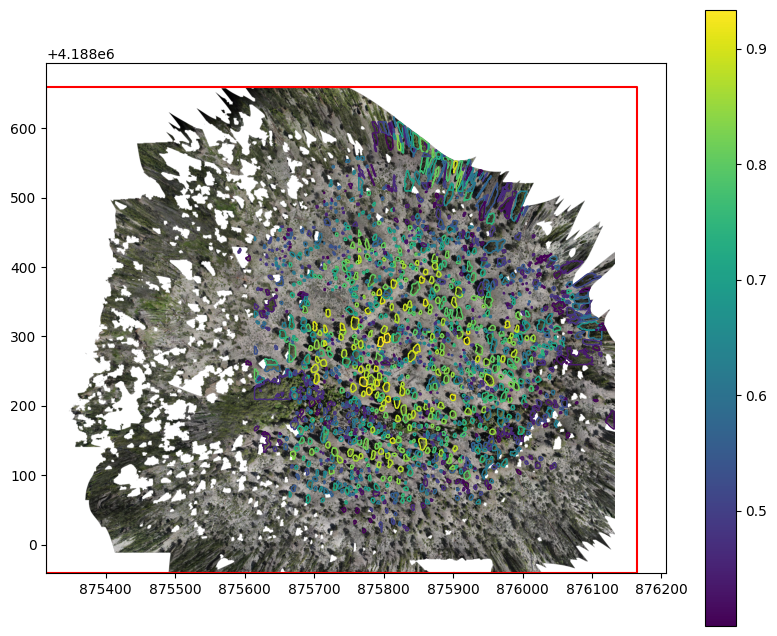

<Axes: >

In [10]:
# Run NMS to suppress overlapping detections
NMS_outputs = multi_region_NMS(
    outputs,
    confidence_column="score",
    threshold=IOU_NMS_THRESHOLD,
)

# Visualize the post-processed detections
NMS_outputs.plot(
    visualization_column="score", bounds_color="r", raster_file=ORTHO_FILE_PATH
)

In [ ]:
# Save as a gpkg file for later use if needed
NMS_outputs.save(
    "/ofo-share/repos/amritha/tree-detection-framework/data/saved-gpkgs/sam3_outputs/0202_001011_001012_sam3.gpkg"
)

2026-03-24 18:07:13,721 - INFO - Created 1,571 records


Next step is to evaluate these detections againt field identified treetops (ground truth)

In [ ]:
# Load the field trees data and the corresponding CHM
FIELD_TREES_PATH = "/ofo-share/project-data/species-prediction-project/intermediate/shifted_field_trees_12_12/0202_001011_001012.gpkg"
CHM_PATH = "/ofo-share/project-data/species-prediction-project/intermediate/CHMs/0202_001011_001012.tif"

# Read field trees file
gdf_field_trees = gpd.read_file(FIELD_TREES_PATH)

# Convert SAM3 polygons to points for evaluation.
# The "chm_max" method uses the CHM to find the local maximum within each predicted polygon.
sam3_outputs = polygons_to_points(NMS_outputs, method="chm_max", chm_path=CHM_PATH, erosion_distance=0.1)

The CHM does not cover the entire extent of the orthomosaic. Display an overlay to visualize this.

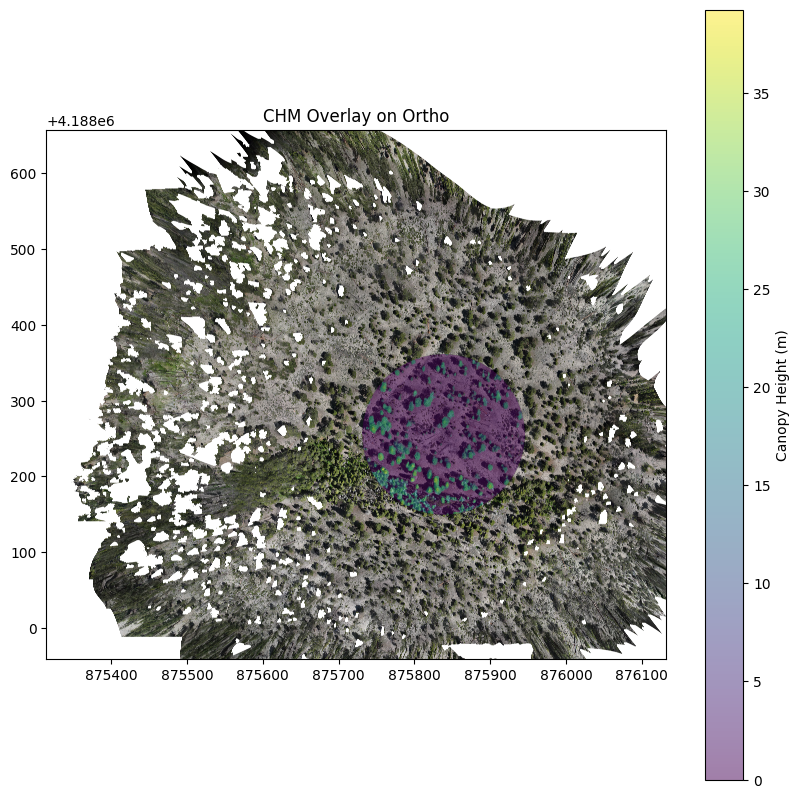

In [13]:
plot_ortho_chm_overlay(
    ortho_path=ORTHO_FILE_PATH,
    chm_path=CHM_PATH)

Run evaluation

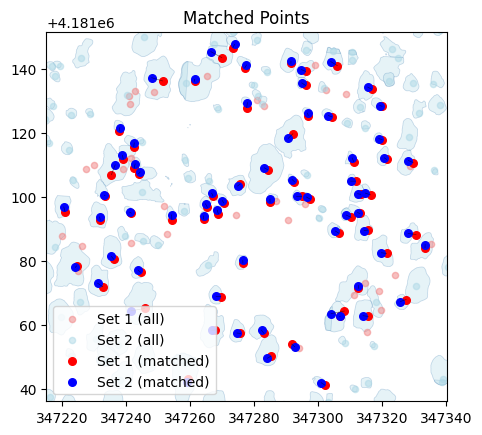

Total number of matches:  70
P, R, F1:  0.04455760661998727 0.6796116504854369 0.08363201911589008


In [18]:
matches = match_points(
    gdf_field_trees,  # "ground truth" tree top points
    sam3_outputs,  # SAM3 predictions with derived "points" for evaluation
    height_column_1="height",
    height_column_2="height",
    height_threshold=lambda h: 0.7 * h,
    vis=True,
)

print("Total number of matches: ", len(matches))
precision, recall, f1_score = assess_matches(
    matches, n_ground_truth=len(gdf_field_trees), n_predictions=len(sam3_outputs)
)
print("P, R, F1: ", precision, recall, f1_score)